In [43]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
import copy
import json
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

import torch
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from latent_model.temporal_prediction import create_models_list, create_loaders
from simulation_encoder.models.model_retrieval import load_models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
"""Utility Functions"""
def plot_regression_results(y_true, y_pred, label_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label="Ideal Fit")
    plt.title(f"Parity Plot for {label_type}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_classification_results(y_true, y_pred, title, class_names, save_path,
                                font_size: int = 0, show: bool = True):
    
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)), normalize="true")

    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Reds",
        cbar=False,
        ax=ax,
        annot_kws={"size": font_size}
    )

    ax.set_title("")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(left=False, bottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.subplots_adjust(left=0, right=1, top=1, bottom=0)

    fig.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0)

    if show:
        plt.show()
    else:
        plt.close(fig)

In [ ]:
study_name = "cae-architecture-gastruloid"
results_path = f"results/{study_name}"
data_type = "gastruloid"

In [46]:
if data_type == "arcade":
    seq_len = 15
elif data_type == "gastruloid":
    seq_len = 9
elif data_type == "nasa":
    seq_len = 3
else:
    raise ValueError(f"Unknown data type: {data_type}")
loaders = create_loaders(results_path, seq_len=seq_len, random_split=True)
loaders = dict(sorted(loaders.items()))

temporal_models = defaultdict(lambda: defaultdict(list))
for model_name in os.listdir(results_path):
    model_path = f"{results_path}/{model_name}/_best_model"
    for dataset_name in os.listdir(model_path):
        loader = loaders[model_name][dataset_name]
        num_dims = loader.num_dims
        temporal_models[model_name][dataset_name] = create_models_list(
            input_size=num_dims, output_size=1, classification=True
        )
temporal_models = dict(sorted(temporal_models.items()))

if data_type == "arcade":
    inverse_mapping = {0: "colony", 1: "tissue"}
    cell_context_map = {"C": 0, "CH": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([cell_context_map[arr.split("_")[0]] for arr in sample_id])
elif data_type == "gastruloid":
    def transform_sample_id(sample_id):
        return torch.Tensor([(int(arr.split("_")[0][-1]) - 1) % 2 for arr in sample_id])
    inverse_mapping = {0: "euploid", 1: "anueploid"}
elif data_type == "nasa":
    radiation_map = {"Fe": 0, "X-ray": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([radiation_map[arr.split("_")[-1]] for arr in sample_id])
    inverse_mapping = {0: "Fe", 1: "X-ray"}

# Latent dim preditions

In [47]:
patience, max_epochs = 5, 50
best_models = defaultdict(dict)

for model_name, dataset in temporal_models.items():
    for dataset_name, models in dataset.items():
        
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train = torch.cat([e for e, _ in train_loader], dim=0)
        mean, std = all_train.mean(0, keepdim=True), all_train.std(0, keepdim=True)

        all_train = torch.cat([e for e, _ in train_loader], dim=0)
        mean, std = all_train.mean(0, keepdim=True), all_train.std(0, keepdim=True)
        normalized = (all_train - mean) / std

        dataset_best_loss   = float("inf")
        dataset_best_model  = None

        for model in models:
            best_weights = None
            best_loss = float("inf")
            no_improvement_count = 0

            for epoch in range(max_epochs):
                model.train()
                for embeddings, sample_id in train_loader:
                    x_batch = (embeddings - mean) / std
                    y_batch = transform_sample_id(sample_id)
                    model.optimizer.zero_grad()
                    y_pred = model(x_batch)
                    loss = model.criterion(y_pred.flatten(), y_batch)
                    loss.backward()
                    model.optimizer.step()

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        x_batch = (embeddings - mean) / std
                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(x_batch)
                        val_loss += model.criterion(y_pred.flatten(), y_batch).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_weights = copy.deepcopy(model.state_dict())
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1
                    if no_improvement_count >= patience:
                        break

            if best_weights is not None:
                model.load_state_dict(best_weights)

            if best_loss < dataset_best_loss:
                dataset_best_loss  = best_loss
                dataset_best_model = copy.deepcopy(model)

        best_models[model_name][dataset_name] = copy.deepcopy(dataset_best_model)
        print(dataset_best_model)

print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

LSTMModel(
  (lstm): LSTM(16, 32, num_layers=3, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): MSELoss()
)
Training complete
Training samples: 669
Validation samples: 168
Testing samples: 210


--------- Training neuralop-16 ------------
              precision    recall  f1-score   support

   anueploid       0.69      0.92      0.79       343
     euploid       0.87      0.57      0.69       326

    accuracy                           0.75       669
   macro avg       0.78      0.74      0.74       669
weighted avg       0.78      0.75      0.74       669

--------- Test neuralop-16 ------------
              precision    recall  f1-score   support

   anueploid       0.62      0.89      0.73        98
     euploid       0.84      0.52      0.64       112

    accuracy                           0.69       210
   macro avg       0.73      0.70      0.68       210
weighted avg       0.74      0.69      0.68       210



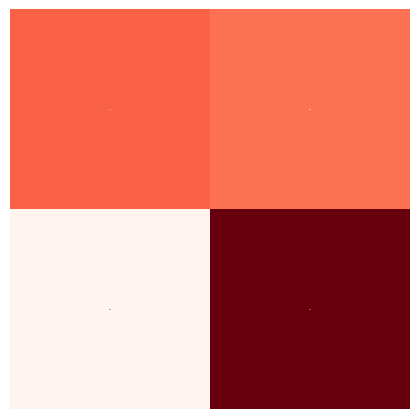

In [48]:
for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train_embeddings = []
        for embeddings, _ in train_loader:
            all_train_embeddings.append(embeddings)

        all_train_embeddings = torch.cat(all_train_embeddings, dim=0)
        mean = all_train_embeddings.mean(dim=0, keepdim=True)
        std = all_train_embeddings.std(dim=0, keepdim=True)

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []
        
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in train_loader:
                x_batch = (embeddings - mean) / std
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
                sample_id_list.extend(sample_id)
                
        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        class_names = inverse_mapping.values()
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print(f"--------- Training {model_name} ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_train.png"
        # plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []
        
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = (embeddings - mean) / std
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
                sample_id_list.extend(sample_id)
                
        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        class_names = inverse_mapping.values()
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print(f"--------- Test {model_name} ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_test.png"
        plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

In [49]:
def permutation_importance_aggregated(model, test_loader, transform_sample_id, baseline_score, num_iterations=10):
    model.eval()
    num_features = next(iter(test_loader))[0].shape[-1]
    importance_scores = np.zeros(num_features)

    for _ in range(num_iterations):
        iteration_importance = []
        for feature_idx in range(num_features):
            y_pred_permuted = []
            y_true = []

            with torch.no_grad():
                for embeddings, sample_id in test_loader:
                    permuted_embeddings = embeddings.clone()
                    permuted_embeddings[:, :, feature_idx] = permuted_embeddings[:, torch.randperm(permuted_embeddings.size(1)), feature_idx]

                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(permuted_embeddings)

                    y_true.extend(y_batch.numpy())
                    y_pred_permuted.extend((y_pred.flatten().numpy() > 0.5).astype(int))

            permuted_score = accuracy_score(y_true, y_pred_permuted)
            importance = baseline_score - permuted_score
            iteration_importance.append(importance)

        importance_scores += np.array(iteration_importance)

    importance_scores /= num_iterations
    feature_importance = sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)
    return feature_importance

def visualize_feature_tuning(model, latent_sample, feature_idx, variation_range=(-3, 3), steps=7):
    half_steps = steps // 2
    feature_values = torch.linspace(variation_range[0], variation_range[1], steps)

    fig, axes = plt.subplots(len(latent_sample), steps, figsize=(3 * steps, 3 * len(latent_sample)))
    if len(latent_sample) == 1:
        axes = axes[None, :]

    for row, latent_vector in enumerate(latent_sample):
        with torch.no_grad():
            original_image = model.decode_image(latent_vector.unsqueeze(0)).squeeze().detach().cpu().numpy()

        for col, val in enumerate(feature_values):
            modified_latent = latent_vector.clone()

            if col == half_steps:
                image_to_plot = original_image
                title = "Original"
                cmap = 'gray'
                vmin = vmax = None
            else:
                modified_latent[feature_idx] += val
                with torch.no_grad():
                    modified_image = model.decode_image(modified_latent.unsqueeze(0)).squeeze().detach().cpu().numpy()
                diff_image = modified_image - original_image
                image_to_plot = diff_image
                title = f"{val.item():+.2f}"
                cmap = 'RdBu'
                vmax = np.max(np.abs(diff_image))
                vmin = -vmax

            axes[row, col].imshow(image_to_plot, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row, col].set_title(title)
            axes[row, col].axis('off')

    fig.savefig(f"figures/feature_tuning_{model.name}_{latent_sample.size(1)}-{feature_idx}.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [50]:
num_iterations = 25
top_features = defaultdict(lambda: defaultdict(list))
for model_name, dataset in best_models.items():
    top_features[model_name] = {}
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")
        y_true_labels, y_pred_labels = [], []

        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = embeddings
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend((y_pred.flatten().numpy() > 0.5).astype(int))

        baseline_acc = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\nBaseline Accuracy for {model_name} | {dataset_name}: {baseline_acc:.4f}")

        feature_importances = permutation_importance_aggregated(
            model, test_loader, transform_sample_id, baseline_acc, num_iterations=num_iterations
        )
        top_features[model_name][dataset_name] = feature_importances
        print(f"Average FI for classificaiton (over {num_iterations} iterations):")
        for idx, imp in feature_importances:
            print(f"  Latent dimension {idx}: importance = {imp:.4f}")


Baseline Accuracy for neuralop-16 | gastruloid_processed_128: 0.6619
Average FI for classificaiton (over 25 iterations):
  Latent dimension 2: importance = 0.0078
  Latent dimension 0: importance = 0.0070
  Latent dimension 10: importance = 0.0034
  Latent dimension 3: importance = 0.0023
  Latent dimension 5: importance = 0.0004
  Latent dimension 15: importance = -0.0006
  Latent dimension 7: importance = -0.0029
  Latent dimension 9: importance = -0.0029
  Latent dimension 11: importance = -0.0040
  Latent dimension 14: importance = -0.0042
  Latent dimension 8: importance = -0.0044
  Latent dimension 13: importance = -0.0053
  Latent dimension 12: importance = -0.0082
  Latent dimension 4: importance = -0.0107
  Latent dimension 6: importance = -0.0110
  Latent dimension 1: importance = -0.0261


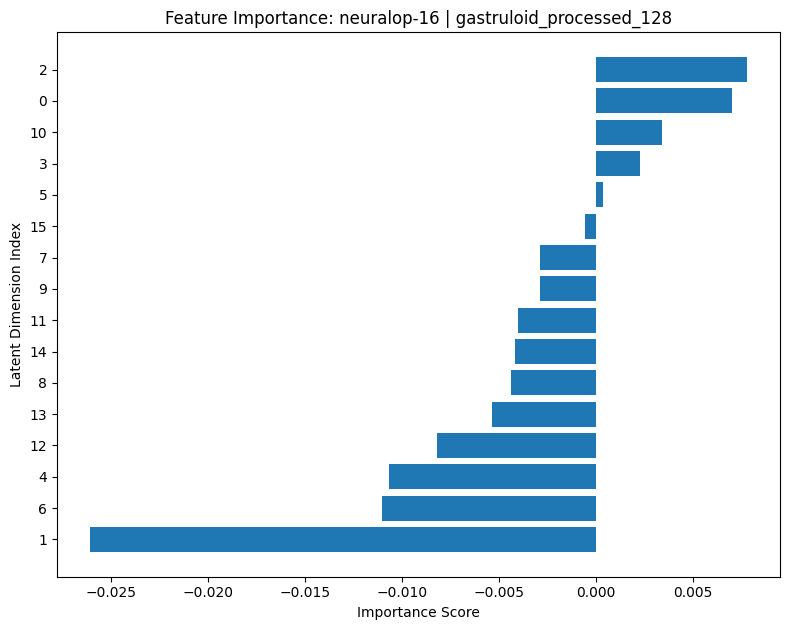

In [51]:
for model_name, dataset_importances in top_features.items():
    for dataset_name, importances in dataset_importances.items():
        sorted_importances = sorted(importances, key=lambda x: x[1], reverse=True)
        feature_indices, importance_values = zip(*sorted_importances)

        plt.figure(figsize=(8, len(feature_indices) * 0.4))
        plt.barh(range(len(feature_indices)), importance_values, tick_label=feature_indices)
        plt.xlabel("Importance Score")
        plt.ylabel("Latent Dimension Index")
        plt.title(f"Feature Importance: {model_name} | {dataset_name}")
        plt.gca().invert_yaxis()  # most important on top
        plt.tight_layout()
        plt.show()

In [52]:
all_results_data = {
    "study_name": study_name,
    "model_dataset_results": []
}

for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")
        

        model.eval()
        correct = []
        incorrect = []
        for loader in [train_loader, val_loader, test_loader]:
            y_true_labels = []
            y_pred_labels = []
            sample_id_list = []

            with torch.no_grad():
                for embeddings, sample_id in loader:
                    x_batch = embeddings
                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(x_batch)

                    y_true_labels.extend(y_batch.numpy())
                    y_pred_labels.extend(y_pred.flatten().numpy())
                    sample_id_list.extend(sample_id)

            y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
            y_true_original = [inverse_mapping[label] for label in y_true_labels]
            y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

            correct.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt == yp])
            incorrect.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt != yp])

        current_model_dataset_results = {
            "model_name": model_name,
            "dataset_name": dataset_name,
            "total_correct": len(correct),
            "total_incorrect": len(incorrect),
            "correct_predictions": correct,
            "incorrect_predictions": incorrect
        }

        all_results_data["model_dataset_results"].append(current_model_dataset_results)

json_filename = f"results_downstream/{study_name}_classification_results.json"
with open(json_filename, 'w') as f:
    json.dump(all_results_data, f, indent=4)

# PCA predictions

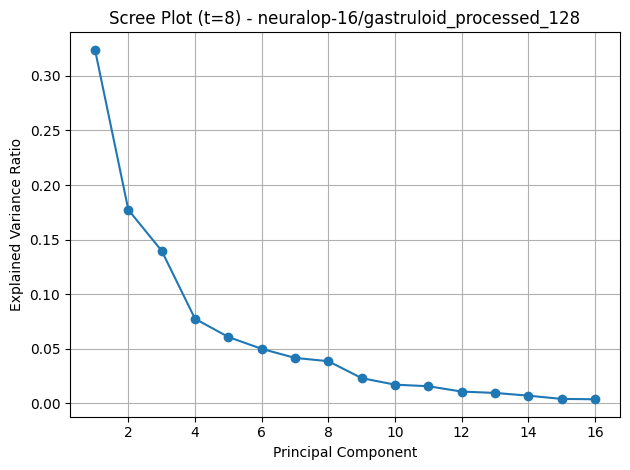

In [53]:
pcas = defaultdict(dict)
n_components = 16

for model_name, dataset in temporal_models.items():
    for dataset_name, models in dataset.items():

        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train = torch.cat([e for e, _ in train_loader], dim=0)
        mean, std = all_train.mean(0, keepdim=True), all_train.std(0, keepdim=True)
        normalized = (all_train - mean) / std

        T = normalized.shape[1]
        

        pca_list = []
        variance_explained = []
        for t in range(T):
            pca_t = PCA()
            pca_t.fit(normalized[:, t].numpy())

            if t == 8:
                plt.figure()
                plt.plot(range(1, len(pca_t.explained_variance_ratio_) + 1),
                         pca_t.explained_variance_ratio_, marker='o')
                plt.title(f"Scree Plot (t={t}) - {model_name}/{dataset_name}")
                plt.xlabel("Principal Component")
                plt.ylabel("Explained Variance Ratio")
                plt.grid(True)
                plt.tight_layout()
                plt.show()

            pca_t_reduced = PCA(n_components=n_components)
            pca_t_reduced.fit(normalized[:, t].numpy())
            pca_list.append(pca_t_reduced)
            variance_explained.append(pca_t.explained_variance_)

        pcas[model_name][dataset_name] = {
            "pca_list": pca_list,
            "mean": mean,
            "std": std,
            "variance_explained": variance_explained
        }

In [54]:
patience, max_epochs = 5, 50
best_pca_models = defaultdict(dict)

for model_name, dataset in temporal_models.items():
    for dataset_name, models in dataset.items():

        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        pca_info = pcas[model_name][dataset_name]
        pca_list = pca_info["pca_list"]
        mean = pca_info["mean"]
        std = pca_info["std"]

        dataset_best_loss = float("inf")
        dataset_best_model = None

        for model in models:
            best_weights = None
            best_loss = float("inf")
            no_improvement_count = 0

            for epoch in range(max_epochs):
                model.train()
                for embeddings, sample_id in train_loader:
                    y_batch = transform_sample_id(sample_id)

                    model.optimizer.zero_grad()
                    y_pred = model(embeddings)
                    loss = model.criterion(y_pred.flatten(), y_batch)
                    loss.backward()
                    model.optimizer.step()

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(embeddings)
                        val_loss += model.criterion(y_pred.flatten(), y_batch).item()
                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_weights = copy.deepcopy(model.state_dict())
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1
                    if no_improvement_count >= patience:
                        break

            if best_weights is not None:
                model.load_state_dict(best_weights)

            if best_loss < dataset_best_loss:
                dataset_best_loss = best_loss
                dataset_best_model = copy.deepcopy(model)

        best_pca_models[model_name][dataset_name] = copy.deepcopy(dataset_best_model)
        print(dataset_best_model)

print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

LSTMModel(
  (lstm): LSTM(16, 32, num_layers=3, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
  (out_layer): Sigmoid()
  (criterion): MSELoss()
)
Training complete
Training samples: 669
Validation samples: 168
Testing samples: 210


--------- Training neuralop-16 ------------
              precision    recall  f1-score   support

   anueploid       0.68      0.95      0.79       343
     euploid       0.90      0.52      0.66       326

    accuracy                           0.74       669
   macro avg       0.79      0.74      0.73       669
weighted avg       0.79      0.74      0.73       669

--------- Test neuralop-16 ------------
              precision    recall  f1-score   support

   anueploid       0.61      0.93      0.74        98
     euploid       0.89      0.48      0.62       112

    accuracy                           0.69       210
   macro avg       0.75      0.71      0.68       210
weighted avg       0.76      0.69      0.68       210



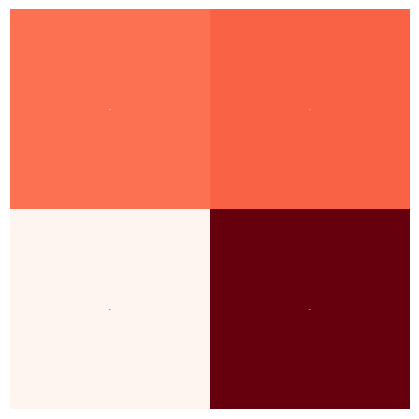

In [55]:
for model_name, dataset in best_pca_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        test_loader = loader.get_dataloader("test")

        pca_info = pcas[model_name][dataset_name]
        pca_list = pca_info["pca_list"]
        mean = pca_info["mean"]
        std = pca_info["std"]

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []

        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in train_loader:
                y_batch = transform_sample_id(sample_id)
                y_pred = model(embeddings)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
                sample_id_list.extend(sample_id)

        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        class_names = inverse_mapping.values()
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print(f"--------- Training {model_name} ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_train.png"
        # plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []

        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                y_batch = transform_sample_id(sample_id)
                y_pred = model(embeddings)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
                sample_id_list.extend(sample_id)

        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print(f"--------- Test {model_name} ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_test.png"
        plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

In [56]:
def permutation_importance_pca_aggregated(model, test_loader, transform_sample_id, baseline_score, num_iterations=10):
    model.eval()
    num_features = next(iter(test_loader))[0].shape[-1]
    importance_scores = np.zeros(num_features)

    for _ in range(num_iterations):
        iteration_importance = []
        for feature_idx in range(num_features):
            y_pred_permuted = []
            y_true = []

            with torch.no_grad():
                for pca_embeddings, sample_id in test_loader:
                    permuted_embeddings = pca_embeddings.clone()
                    # Permute across the time dimension (dim=1)
                    permuted_embeddings[:, :, feature_idx] = permuted_embeddings[:, torch.randperm(permuted_embeddings.size(1)), feature_idx]

                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(permuted_embeddings)

                    y_true.extend(y_batch.numpy())
                    y_pred_permuted.extend((y_pred.flatten().numpy() > 0.5).astype(int))

            permuted_score = accuracy_score(y_true, y_pred_permuted)
            importance = baseline_score - permuted_score
            iteration_importance.append(importance)

        importance_scores += np.array(iteration_importance)

    importance_scores /= num_iterations
    feature_importance = sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)
    return feature_importance

def visualize_pca_feature_tuning(
    pca_info,
    model,
    pca_sample,
    feature_idx,
    time_idx=8,
    variation_range=(-3, 3),
    steps=7,
    include_center_image=False,
):
    assert steps % 2 == 1, "Steps must be odd to have a center image"
    original_pca = pca_sample[time_idx]
    pca_list = pca_info["pca_list"]
    pca = pca_list[time_idx]
    mean = pca_info["mean"][0, time_idx].numpy()
    std = pca_info["std"][0, time_idx].numpy()

    feature_values = np.linspace(*variation_range, steps)

    # Get the original image once
    original_inv = pca.inverse_transform(original_pca)
    original_denorm = original_inv * std + mean
    original_img = model.decode_image(torch.tensor(original_denorm).float().unsqueeze(0)).squeeze().detach().cpu().numpy()

    if include_center_image:
        fig, axes = plt.subplots(1, steps, figsize=(3 * steps, 3))
    else:
        half = steps // 2
        fig, axes = plt.subplots(1, steps - 1, figsize=(3 * (steps - 1) + 0.5, 3))  # +0.5 for spacing between halves

    img_idx = 0
    for col, val in enumerate(feature_values):
        if not include_center_image and col == steps // 2:
            continue  # skip center image

        perturbed = original_pca.copy()
        perturbed[feature_idx] += val
        inverse = pca.inverse_transform(perturbed)
        denorm = inverse * std + mean
        decoded = model.decode_image(torch.tensor(denorm).float().unsqueeze(0)).squeeze().detach().cpu().numpy()

        if include_center_image and col == steps // 2:
            title = "Original"
            cmap = 'gray'
            vmin = vmax = None
        else:
            diff_image = decoded - original_img
            decoded = diff_image
            title = f"{val:+.2f}"
            cmap = 'RdBu'
            vmax = np.max(np.abs(diff_image))
            vmin = -vmax

        axes[img_idx].imshow(decoded, cmap=cmap, vmin=vmin, vmax=vmax)
        # axes[img_idx].set_title(title)
        axes[img_idx].axis('off')
        img_idx += 1

    fig.tight_layout()
    fig.savefig(f"figures/pca_feature_tuning_{model.name}_t{time_idx}_pc{feature_idx}.png", dpi=300, bbox_inches='tight')
    plt.show()

In [57]:
top_pca_features = defaultdict(lambda: defaultdict(list))

for model_name, dataset in best_pca_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader("test")

        y_true_labels, y_pred_labels = [], []
        model.eval()
        with torch.no_grad():
            for pca_embeddings, sample_id in test_loader:
                y_batch = transform_sample_id(sample_id)
                y_pred = model(pca_embeddings)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend((y_pred.flatten().numpy() > 0.5).astype(int))

        baseline_acc = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\nBaseline Accuracy for {model_name} | {dataset_name}: {baseline_acc:.4f}")

        feature_importances = permutation_importance_pca_aggregated(
            model, test_loader, transform_sample_id, baseline_acc, num_iterations=25
        )

        top_pca_features[model_name][dataset_name] = feature_importances
        print("Average FI in PCA space (over 25 iterations):")
        for idx, imp in feature_importances:
            print(f"  PC {idx}: importance = {imp:.4f}")


Baseline Accuracy for neuralop-16 | gastruloid_processed_128: 0.6905
Average FI in PCA space (over 25 iterations):
  PC 1: importance = 0.0539
  PC 4: importance = 0.0183
  PC 0: importance = 0.0170
  PC 12: importance = 0.0114
  PC 6: importance = 0.0091
  PC 14: importance = 0.0086
  PC 10: importance = 0.0059
  PC 15: importance = 0.0042
  PC 3: importance = 0.0040
  PC 13: importance = 0.0036
  PC 2: importance = 0.0019
  PC 8: importance = 0.0011
  PC 5: importance = -0.0006
  PC 11: importance = -0.0030
  PC 9: importance = -0.0036
  PC 7: importance = -0.0038


In [58]:
import random

autoencoders = load_models(results_path, num_timepoints=seq_len, best_models_flag=True)
autoencoders = dict(sorted(autoencoders.items()))

index = None
random_samples = defaultdict(lambda: defaultdict(list))
for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader('test')
        dataset = test_loader.dataset
        if not index:
            index = random.randint(0, len(dataset) - 1)
        latent_sample, sample_id = dataset[idx]
        latent_sample = latent_sample[-1].unsqueeze(0)
        random_samples[model_name][dataset_name] = latent_sample
                

Loading model neuralop_medium (3.41e+07 parameters)


In [59]:
index = None
random_samples_pca = defaultdict(lambda: defaultdict(list))

for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader('test')
        dataset = test_loader.dataset

        if index is None:
            index = random.randint(0, len(dataset) - 1)

        latent_seq, sample_id = dataset[index]
        
        mean = pcas[model_name][dataset_name]["mean"]
        std = pcas[model_name][dataset_name]["std"]
        normalized = (latent_seq - mean) / std 

        pca_list = pcas[model_name][dataset_name]["pca_list"]

        pca_data = []
        for t, pca in enumerate(pca_list):
            flattened = normalized[0, t].numpy().reshape(1, -1)
            transformed = pca.transform(flattened)
            pca_data.append(transformed.squeeze(0))

        pca_transformed = np.stack(pca_data)

        random_samples_pca[model_name][dataset_name] = pca_transformed

neuralop-16


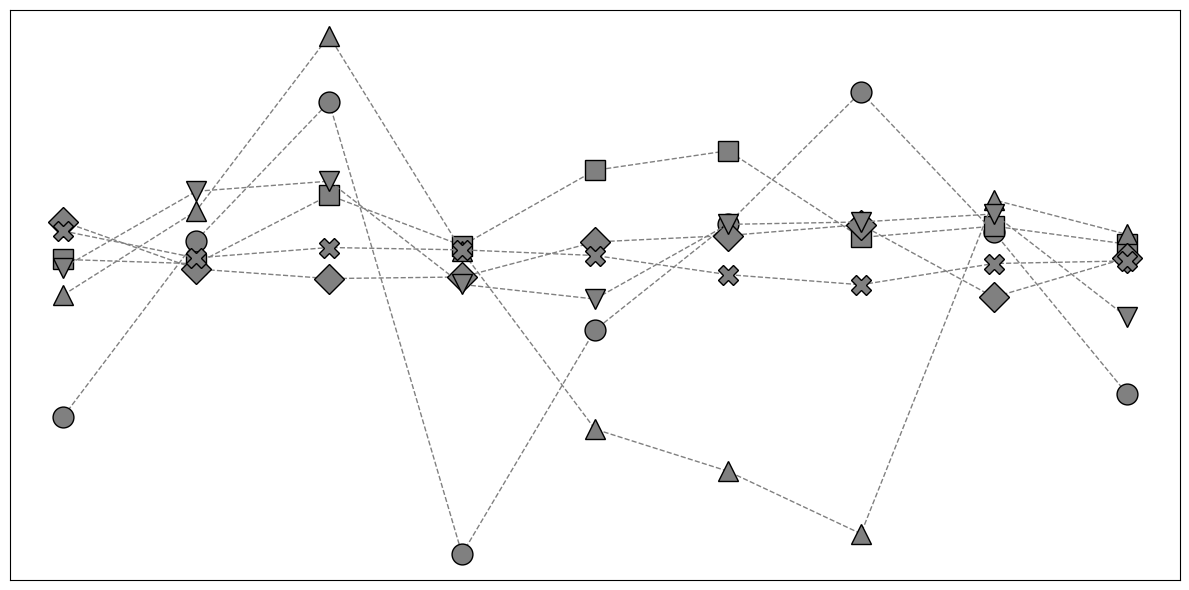

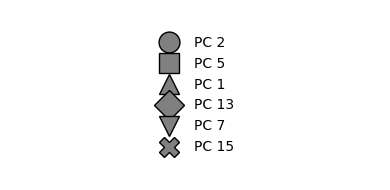

In [60]:
avg_pca_trajectories = defaultdict(lambda: defaultdict(list))

marker_styles = ['o', 's', '^', 'D', 'v', 'X']
gray_color = 'black'
faint_line_color = 'gray'
faint_line_style = '--'

for model_name, dataset in autoencoders.items():
    print(model_name)
    for dataset_name, encoder_model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader("test")
        dataset = test_loader.dataset

        pca_info = pcas[model_name][dataset_name]
        mean = pca_info["mean"]
        std = pca_info["std"]
        pca_list = pca_info["pca_list"]

        num_timepoints = len(pca_list)
        num_pcs = pca_list[0].n_components_
        sum_pca = np.zeros((num_timepoints, num_pcs))
        count = 0

        for raw_seq, _ in dataset:
            raw_seq = raw_seq.unsqueeze(0)
            normalized = (raw_seq - mean) / std
            pca_data = []

            for t, pca in enumerate(pca_list):
                transformed = pca.transform(normalized[0, t].numpy().reshape(1, -1))
                pca_data.append(transformed.squeeze(0))

            sum_pca += np.stack(pca_data, axis=0)
            count += 1

        avg_pca = sum_pca / count
        avg_pca_trajectories[model_name][dataset_name] = avg_pca

        top_pcs = top_pca_features[model_name][dataset_name]
        fig, ax = plt.subplots(figsize=(12, 6))
        lines = []
        labels = []

        for i in range(6):
            pc_idx = top_pcs[i][0]
            marker = marker_styles[i % len(marker_styles)]

            ax.plot(range(num_timepoints), avg_pca[:, pc_idx],
                    color=faint_line_color, linestyle=faint_line_style, linewidth=1.0)

            line = ax.plot(range(num_timepoints), avg_pca[:, pc_idx],
                           label=f"PC {pc_idx+1}", color=gray_color,
                           linestyle='None', marker=marker, markerfacecolor='gray', markersize=15, linewidth=2.0)[0]
            lines.append(line)
            labels.append(f"PC {pc_idx+1}")

        # Publication-style cleanup
        ax.tick_params(axis='x', which='both', length=0, labelbottom=False)
        ax.tick_params(axis='y', which='both', length=0, labelleft=False)
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.grid(False)
        plt.tight_layout()
        plt.savefig(f"figures/gastruloid/pca_trajectory_{model_name}_{dataset_name}.png", dpi=300)
        plt.show()

        # Separate legend
        legend_fig, legend_ax = plt.subplots(figsize=(4, 2))
        legend = legend_ax.legend(handles=lines, labels=labels, loc='center', frameon=False)
        legend_ax.axis('off')
        plt.tight_layout()
        plt.savefig(f"figures/gastruloid/legend_{model_name}_{dataset_name}.png", dpi=300, bbox_inches='tight')
        plt.show()

Model: neuralop-16 Most important PCA feature: 1


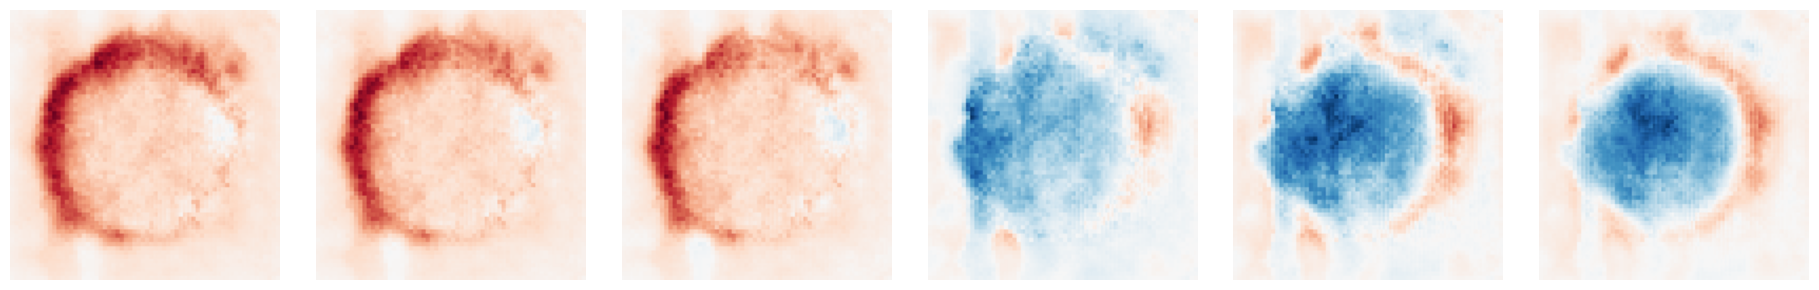

In [61]:
for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        most_important_features = top_pca_features[model_name][dataset_name][0][0]
        print(f"Model: {model_name} Most important PCA feature: {most_important_features}")

        pca_info = pcas[model_name][dataset_name]
        pca_sample = random_samples_pca[model_name][dataset_name]

        encoder_model.eval()
        with torch.no_grad():
            visualize_pca_feature_tuning(
                pca_info,
                encoder_model,
                pca_sample,
                feature_idx=most_important_features,
                time_idx=8,
                variation_range=(-3, 3),
                steps=7
            )

In [62]:
# for model_name, dataset in best_pca_models.items():
#     for dataset_name, model in dataset.items():
#         loader = loaders[model_name][dataset_name]
#         test_loader = loader.get_dataloader("test")
#         pca_info = pcas[model_name][dataset_name]
#         pca_list = pca_info["pca_list"]
#         mean = pca_info["mean"]
#         std = pca_info["std"]
#         variance_explained = pca_info["variance_explained"]

#         timepoint_list = []
#         all_pca_embeddings = []

#         with torch.no_grad():
#             for embeddings, sample_id in test_loader:
#                 for i in range(embeddings.size(0)):
#                     y_batch = transform_sample_id(sample_id)
#                     latent = embeddings[i].cpu().numpy()
#                     latent = (latent - mean[t]) / std[t]
#                     pca = pca_list[t]
#                     pca_embedding = pca.transform(latent.reshape(1, -1)).squeeze()
#                     timepoint_list.append(t)
#                     all_pca_embeddings.append(pca_embedding)

#         # Organize by timepoint
#         tp_to_embeddings = defaultdict(list)
#         for t, emb in zip(timepoint_list, all_pca_embeddings):
#             tp_to_embeddings[t].append(emb)

#         sorted_timepoints = sorted(tp_to_embeddings.keys())
#         num_pcs = all_pca_embeddings[0].shape[0]

#         dim_trajectories = [[] for _ in range(num_pcs)]
#         for t in sorted_timepoints:
#             arr = np.stack(tp_to_embeddings[t])
#             mean_vals = arr.mean(axis=0)
#             for d in range(num_pcs):
#                 dim_trajectories[d].append(mean_vals[d])

#         # Plot
#         fig, ax = plt.subplots(figsize=(12, 6))
#         for d in range(num_pcs):
#             var = variance_explained[d] if d < len(variance_explained) else 0.0
#             ax.plot(sorted_timepoints, dim_trajectories[d], label=f'PC {d+1} ({var:.1%})', linewidth=4)

#         ax.tick_params(axis='x', labelsize=24)
#         ax.tick_params(axis='y', labelsize=24)
#         ax.grid(True)
#         ax.legend(fontsize=14, loc='upper left')
#         plt.title(f'{model_name} | {dataset_name} - PCA Trajectories', fontsize=18)
#         plt.tight_layout()
#         plt.show()

Model: neuralop-16 | Dataset: gastruloid_processed_128 | Timepoint: 8
  Visualizing PC 0


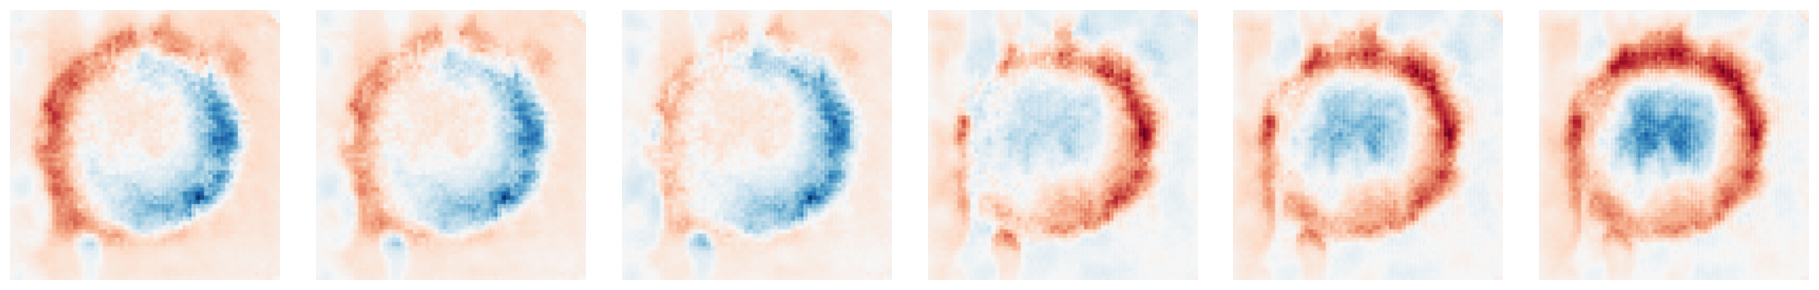

  Visualizing PC 1


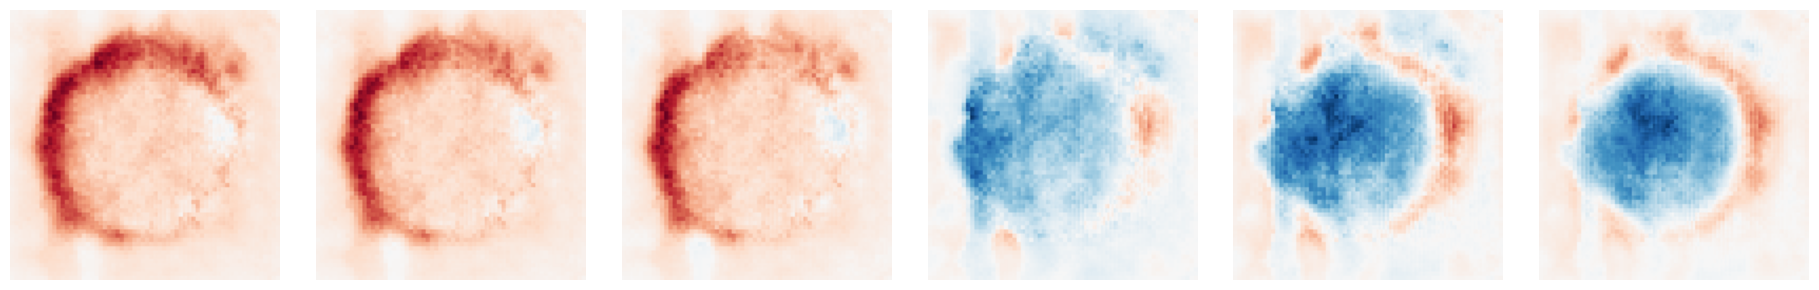

  Visualizing PC 2


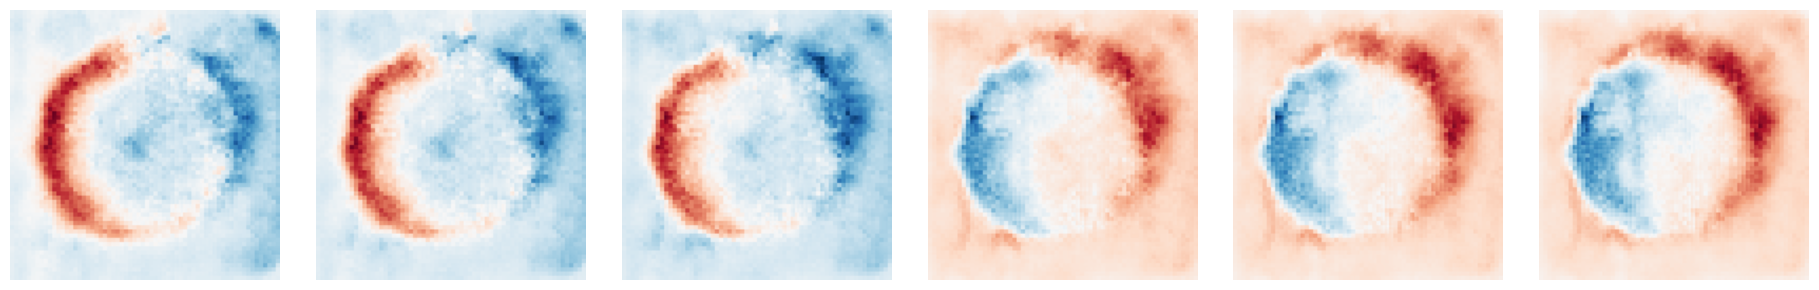

  Visualizing PC 3


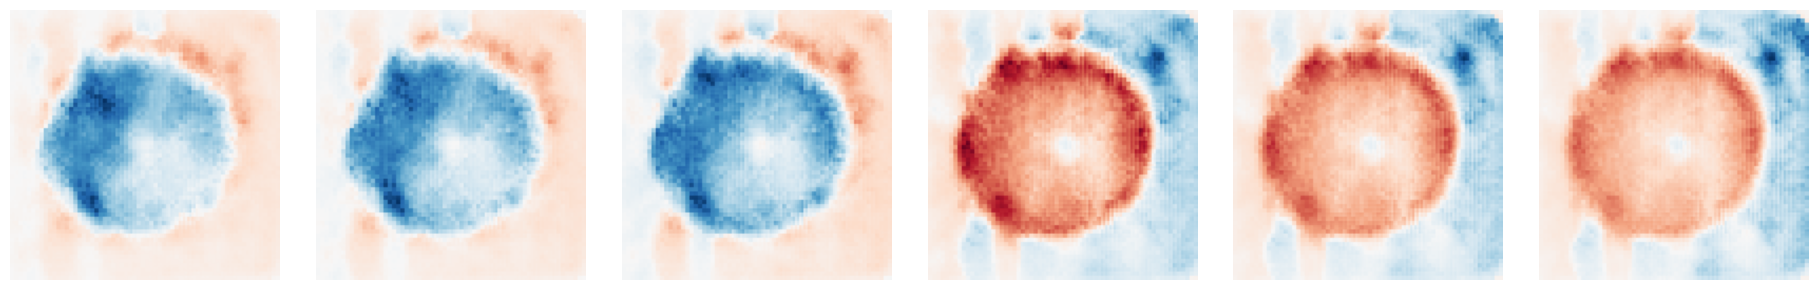

  Visualizing PC 4


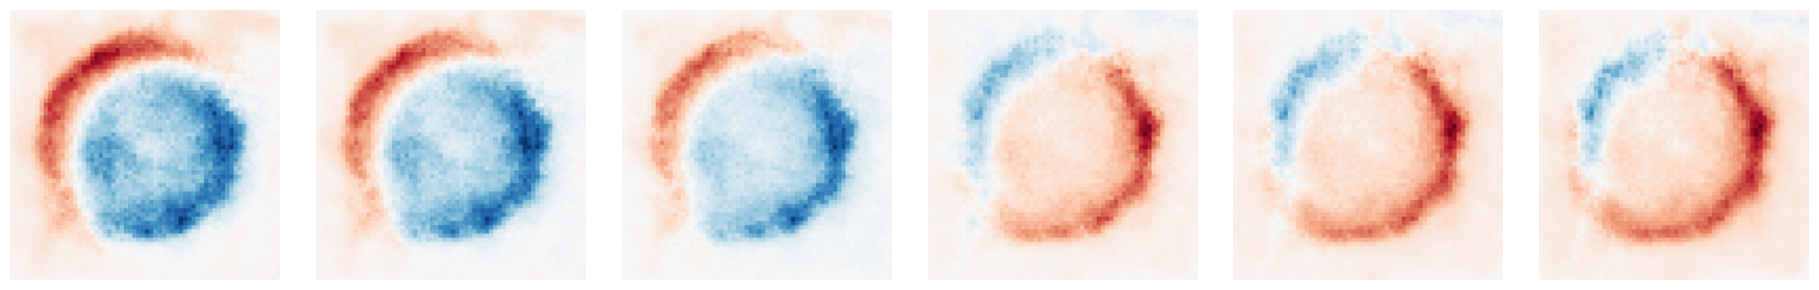

  Visualizing PC 5


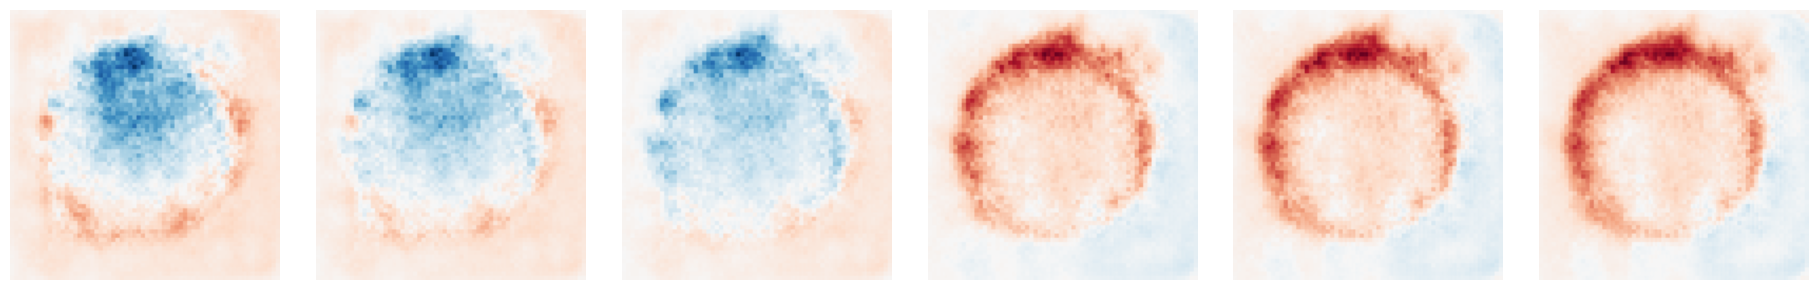

  Visualizing PC 6


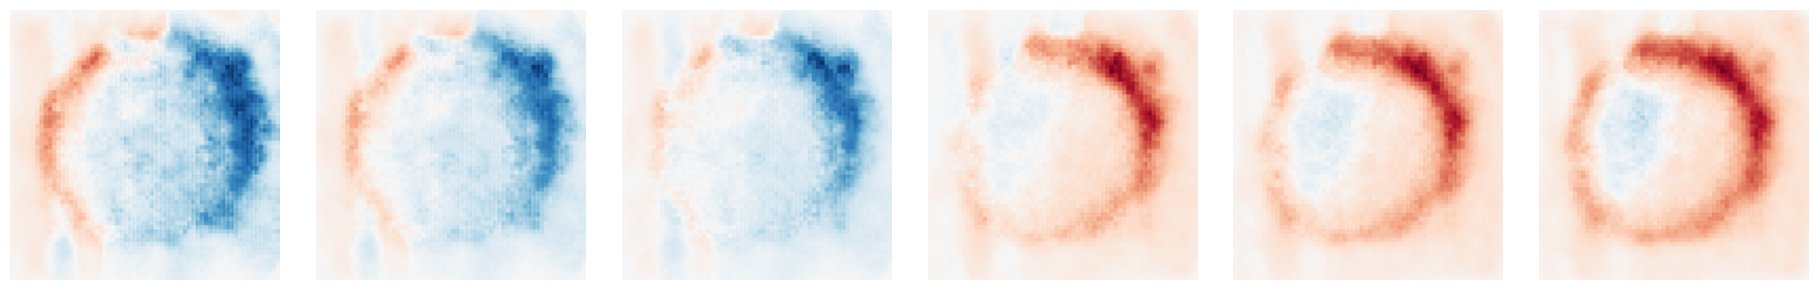

  Visualizing PC 7


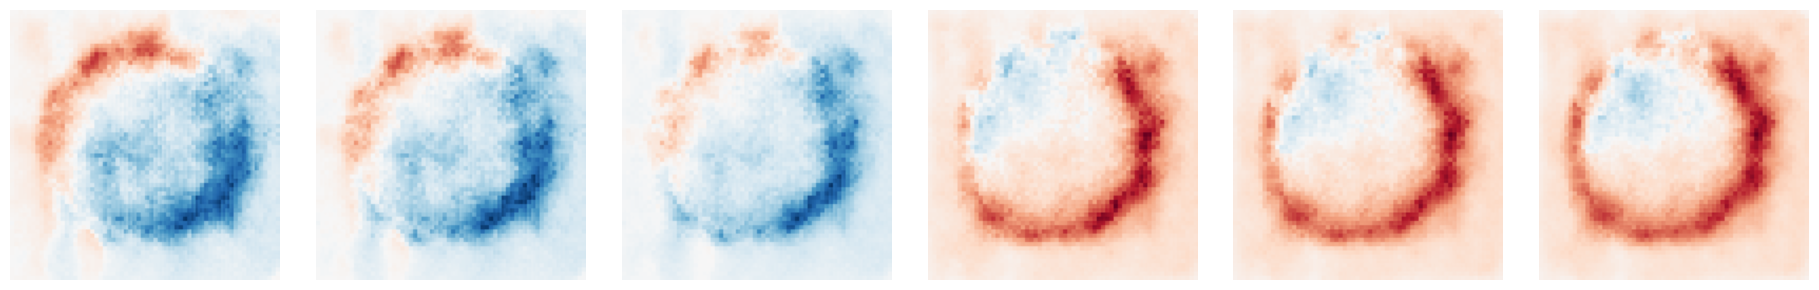

  Visualizing PC 8


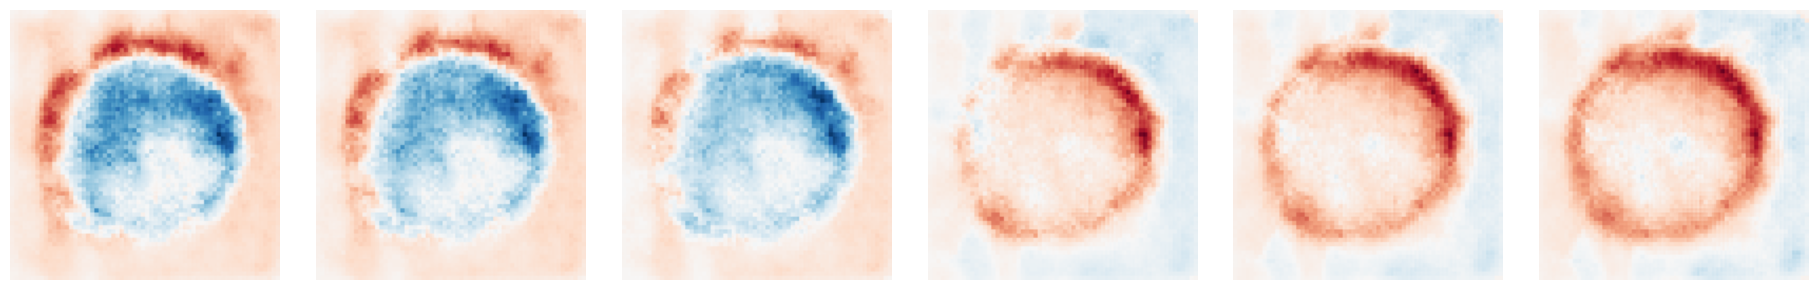

  Visualizing PC 9


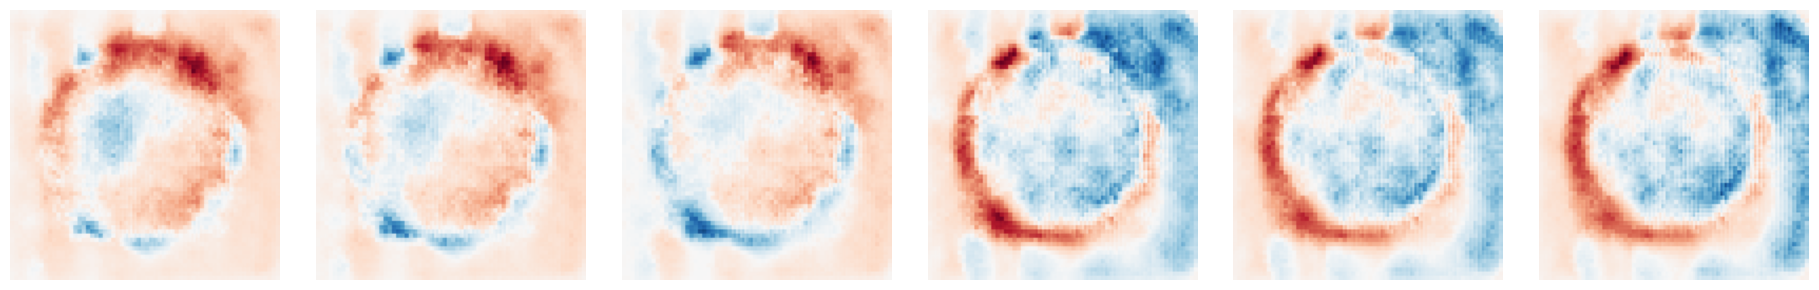

  Visualizing PC 10


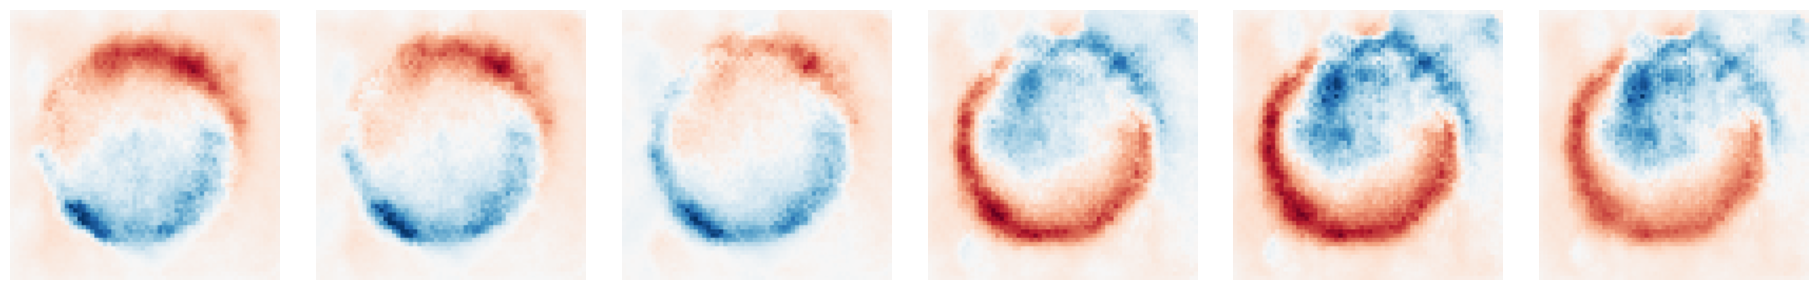

  Visualizing PC 11


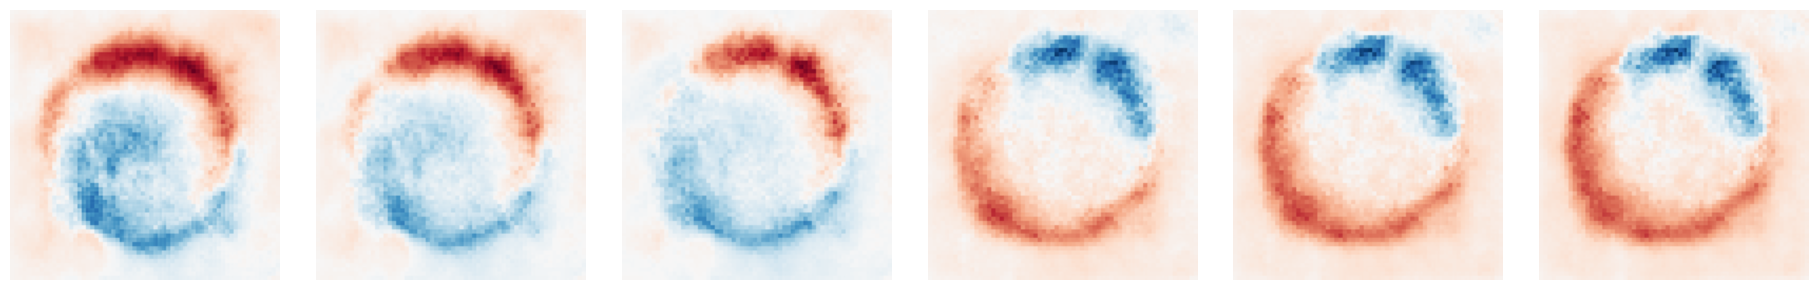

  Visualizing PC 12


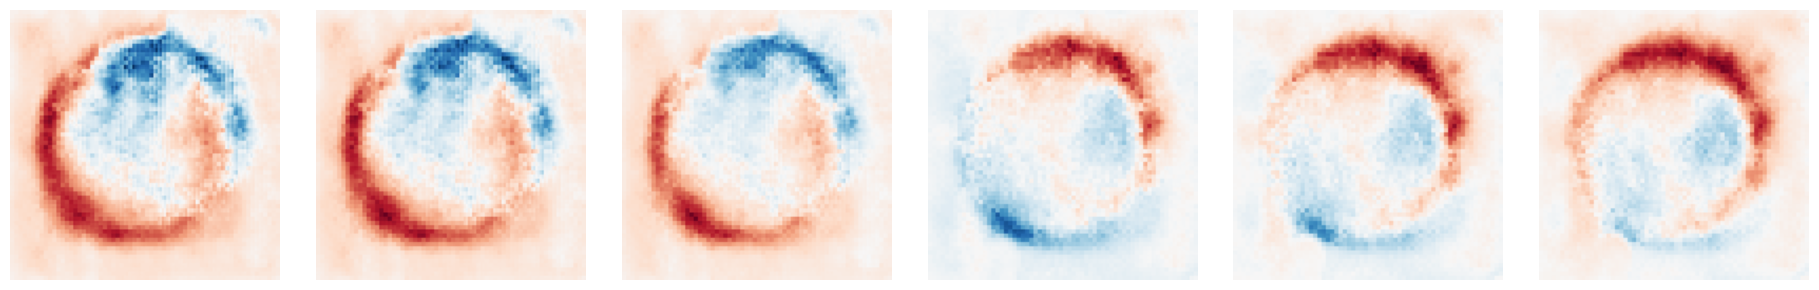

  Visualizing PC 13


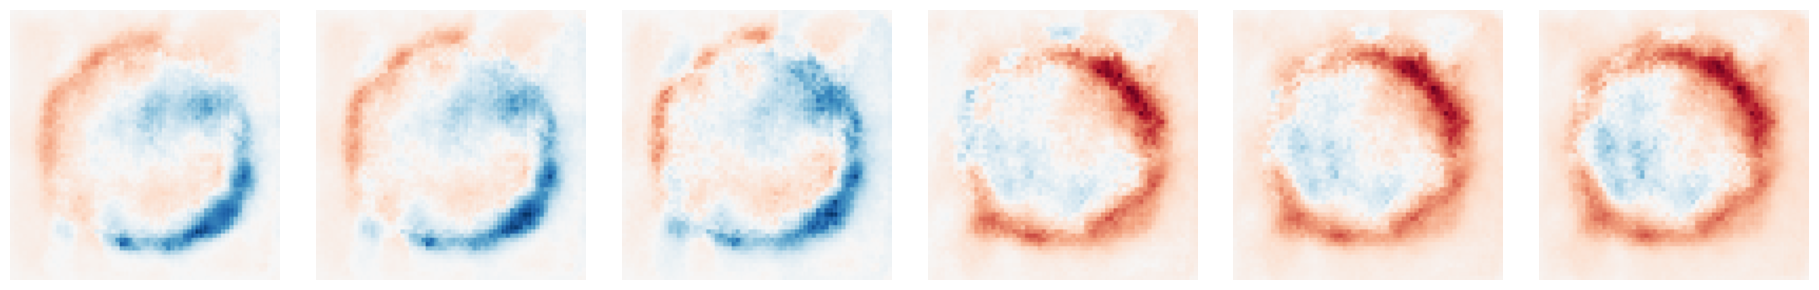

  Visualizing PC 14


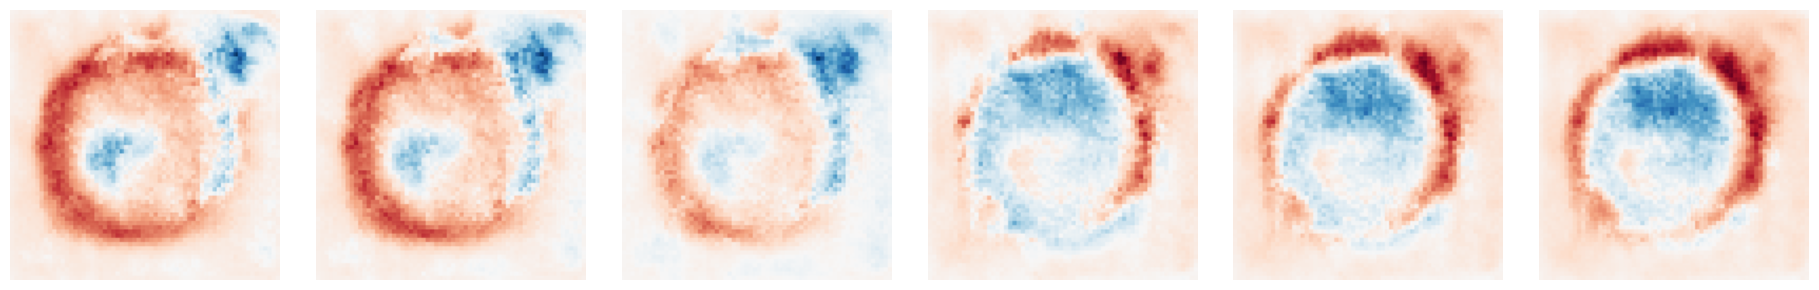

  Visualizing PC 15


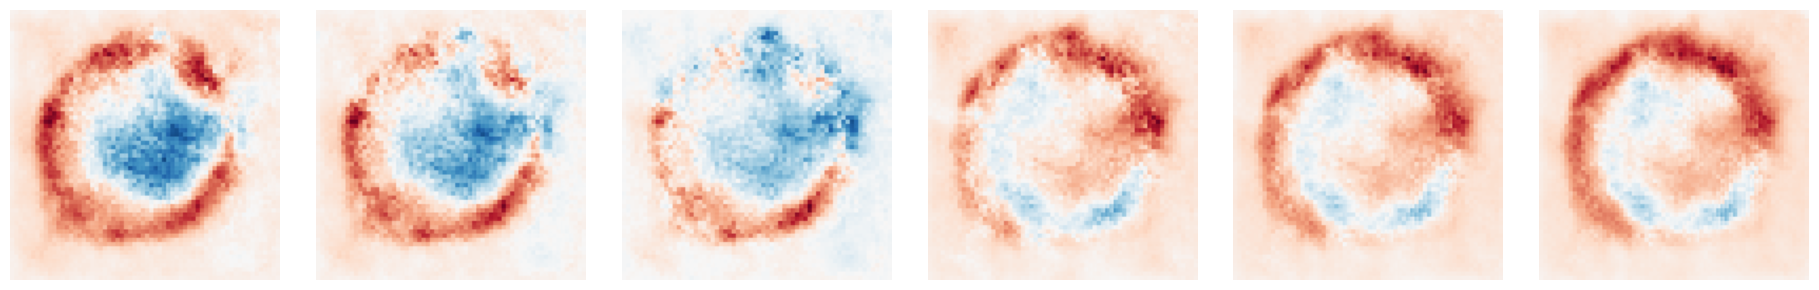

In [63]:
time_idx = 8

for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        # if model_name != "neuralop":
        #     continue
        pca_info = pcas[model_name][dataset_name]
        pca_sample = random_samples_pca[model_name][dataset_name]
        pca_vector = pca_sample[time_idx]
        pca_model = pca_info["pca_list"][time_idx]
        num_pcs = pca_model.components_.shape[0]

        print(f"Model: {model_name} | Dataset: {dataset_name} | Timepoint: {time_idx}")
        encoder_model.eval()
        with torch.no_grad():
            for pc_idx in range(num_pcs):
                print(f"  Visualizing PC {pc_idx}")
                visualize_pca_feature_tuning(
                    pca_info,
                    encoder_model,
                    pca_sample,
                    feature_idx=pc_idx,
                    time_idx=time_idx,
                    variation_range=(-3, 3),
                    steps=7
                )